PROJECT FLOW

In [1]:
# Import required libraries

import pandas as pd          # For data handling
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt   # For visualization

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Accuracy metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
# Load dataset from CSV file

data = pd.read_csv("data.csv")

# Display first 5 rows
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Convert column names to lowercase
# Remove extra spaces

data.columns = data.columns.str.strip().str.lower()

print("Dataset Columns:")
print(data.columns)

# Keep only columns that exist
selected_columns = []

possible_cols = [
    'area',
    'bedrooms',
    'bathrooms',
    'floors',
    'yearbuilt',
    'location',
    'condition',
    'garage',
    'price'
]

for col in possible_cols:
    if col in data.columns:
        selected_columns.append(col)

# Select available columns
data = data[selected_columns]

# Remove missing values
data.dropna(inplace=True)

# Clean text columns if they exist
text_cols = ['location', 'condition', 'garage']

for col in text_cols:
    if col in data.columns:
        data[col] = data[col].astype(str).str.lower().str.strip()

# Convert numeric columns
numeric_cols = ['area', 'bedrooms', 'bathrooms',
                'floors', 'yearbuilt', 'price']

for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove invalid rows
data.dropna(inplace=True)

# Encode categorical columns if present
categorical_cols = []

for col in ['location', 'condition', 'garage']:
    if col in data.columns:
        categorical_cols.append(col)

if categorical_cols:
    data = pd.get_dummies(data, columns=categorical_cols)

# Display cleaned dataset
data.head()

Dataset Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


,area,bedrooms,bathrooms,price
0,7420,4,2,13300000
1,8960,4,4,12250000
2,9960,3,2,12250000
3,7500,4,2,12215000
4,7420,4,1,11410000


In [4]:
# Separate input features and target variable

X = data.drop('price', axis=1)

y = data['price']

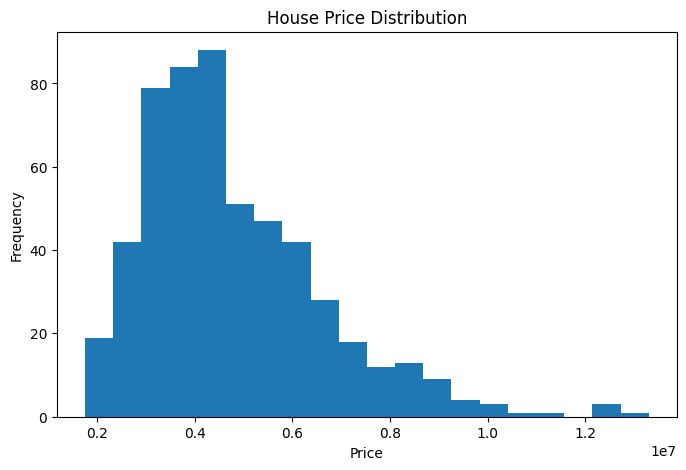

In [5]:
# Plot histogram for house price distribution

plt.figure(figsize=(8,5))

plt.hist(data['price'], bins=20)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("House Price Distribution")

plt.show()

In [6]:
# Separate input features and target variable

X = data.drop('price', axis=1)   # Input features

y = data['price']                # Target output

In [7]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.05,
    random_state=42
)

In [8]:
#(model traing) Create Linear Regression model 

model = LinearRegression()

# Train model using training data
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [9]:
# Predict house prices using test data

y_pred = model.predict(X_test)

# Display first 5 predictions
print(y_pred[:5])

[6475888.67239385 6298438.47195825 3579874.2965542  4325076.06557113
 3946575.01985024]


In [10]:
# Calculate R2 Score 

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.47305341169034876


In [11]:
# Calculate Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

Mean Absolute Error: 1260829.6751819204
Mean Squared Error: 2948708632055.87


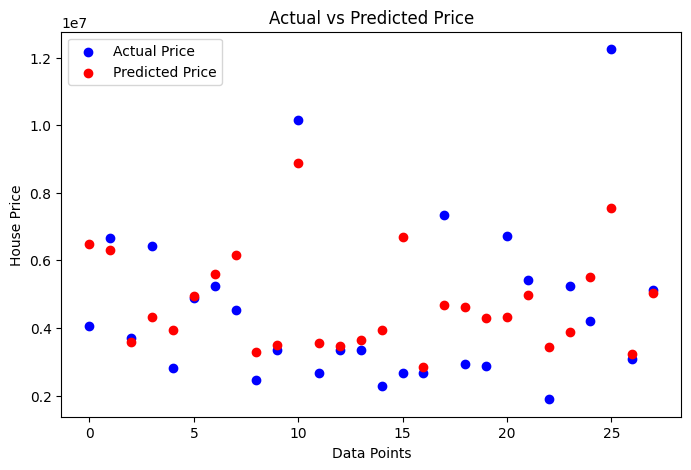

In [12]:
# Plot Actual Price vs Predicted Price

plt.figure(figsize=(8,5))

# Actual values
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual Price')

# Predicted values
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted Price')

plt.xlabel("Data Points")
plt.ylabel("House Price")

plt.title("Actual vs Predicted Price")

plt.legend()

plt.show()

In [13]:
# lab...


In [ ]:
import joblib
joblib.dump(model, "house_price_model.pkl")



['house_price_model.pkl']

In [14]:
# 